In [1]:
import numpy as np
import pandas as pd

In [2]:
%run ANN.ipynb
%run LinearRegression.ipynb

New X_train_prepared shape: (8392, 12)
New y_train shape: (8392,)
Epoch 0, Loss: 32.158593360754516
Epoch 100, Loss: 27.96721513410538
Epoch 200, Loss: 24.52365987683953
Epoch 300, Loss: 21.673150097597606
Epoch 400, Loss: 19.26417631724283
Epoch 500, Loss: 17.12836975453309
Epoch 600, Loss: 15.095478064902341
Epoch 700, Loss: 13.142758845329228
Epoch 800, Loss: 11.539680388208597
Epoch 900, Loss: 10.473813314437702
Epoch 1000, Loss: 9.778052521923723
Epoch 1100, Loss: 9.260319100761093
Epoch 1200, Loss: 8.837650807955862
Epoch 1300, Loss: 8.477252035974479
Epoch 1400, Loss: 8.155104525986092
Epoch 1500, Loss: 7.888220676467741
Epoch 1600, Loss: 7.691003608696081
Epoch 1700, Loss: 7.547501100507073
Epoch 1800, Loss: 7.447185095815178
Epoch 1900, Loss: 7.376326395963764
Epoch 2000, Loss: 7.325157166473703
Epoch 2100, Loss: 7.28745421073522
Epoch 2200, Loss: 7.2566925307177925
Epoch 2300, Loss: 7.234239126699834
Epoch 2400, Loss: 7.219994293221843
Epoch 2500, Loss: 7.210084753879497
Epoc

In [3]:
# X_train_prepared 
# X_test_prepared

#ZSCORE
X_train_data_Z, X_validate_data_Z = z_score(X_train_prepared, X_test_prepared)

#Bias
X_bias_train_data = np.hstack([np.ones((X_train_data_Z.shape[0], 1)), X_train_data_Z])
X_bias_validate_data = np.hstack([np.ones((X_validate_data_Z.shape[0], 1)), X_validate_data_Z])

#Weights
XtX = X_bias_train_data.T @ X_bias_train_data
XtY = X_bias_train_data.T @ y_train

weight = np.linalg.pinv(XtX) @ XtY

In [4]:
def weighted_mean_voting(lr_pred, ann_pred, lr_weight, ann_weight):
    
    lr_pred = lr_pred.reshape(-1, 1)
    ann_pred = ann_pred.reshape(-1, 1)

    ensemble_pred = (lr_weight * lr_pred) + (ann_weight * ann_pred)

    return ensemble_pred

In [5]:
# Predict
lr_train_pred = X_bias_train_data @ weight
lr_test_pred = X_bias_validate_data @ weight

ann_train_pred = np.expm1(model.forward_prop(X_train_prepared))
ann_test_pred = np.expm1(model.forward_prop(X_test_prepared))

# Train
ensemble_train_pred = weighted_mean_voting(
    lr_train_pred,
    ann_train_pred,
    lr_weight=0.7,
    ann_weight=0.3
)

ensemble_test_pred = weighted_mean_voting(
    lr_test_pred,
    ann_test_pred,
    lr_weight=0.7,
    ann_weight=0.3
)

# Calculate RMSE (Root Mean Squared Error)
ensemble_train_rmse = np.sqrt(mean_squared_error(y_train, ensemble_train_pred))
ensemble_test_rmse = np.sqrt(mean_squared_error(y_test, ensemble_test_pred))

# Calculate sMAPE
ensemble_train_smape = smape(y_train.values.reshape(-1, 1), ensemble_train_pred)
ensemble_test_smape = smape(y_test.values.reshape(-1, 1), ensemble_test_pred)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train sMAPE: {train_smape_val:.2f}%")
print(f"Test sMAPE: {test_smape_val:.2f}%")

Train RMSE: 2145834677.33
Test RMSE: 2325130257.43
Train sMAPE: 135.85%
Test sMAPE: 136.41%


# Plots

In [6]:
import plotly.express as px

def rmse_plot(dataset):
    
    fig_rmse = px.bar(
    dataset,
    x='Model',
    y='RMSE',
    color='Dataset',
    barmode='group',
    text_auto='.2f',
    title='RMSE Comparison'
    )
    
    fig_rmse.show()
    
def smape_plot(dataset):
    fig_smape = px.bar(
    dataset,
    x='Model',
    y='sMAPE',
    color='Dataset',
    barmode='group',
    text_auto='.2f',
    title='sMAPE Comparison'
    )

    fig_smape.show()

### Combining all results

In [7]:
results_ensemble = pd.DataFrame({
    'Model': ['Ensemble', 'Ensemble'],
    'Dataset': ['Train', 'Test'],
    'RMSE': [ensemble_train_rmse, ensemble_test_rmse],
    'sMAPE': [ensemble_train_smape, ensemble_test_smape]
})

results_all = pd.concat(
    [results_linearReg, results_ann, results_ensemble],
    ignore_index=True
)

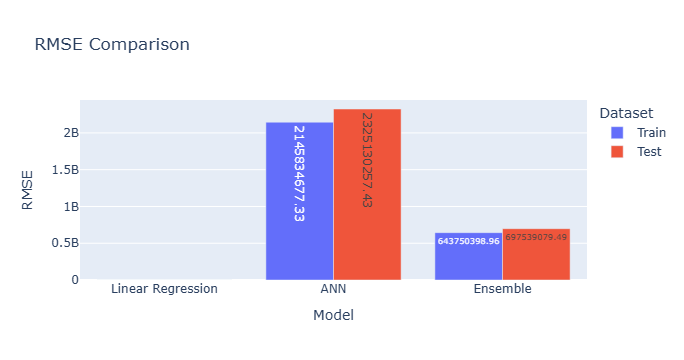

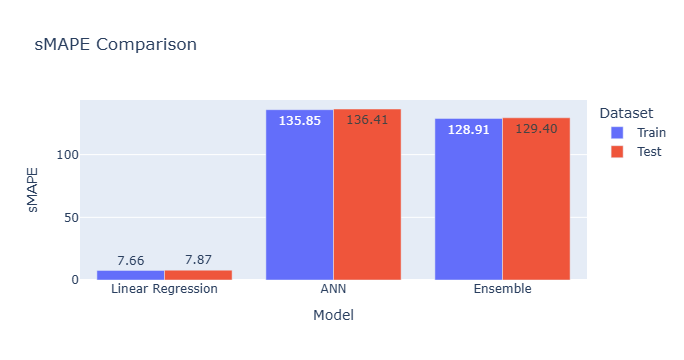

In [12]:
rmse_plot(results_all)
smape_plot(results_all)

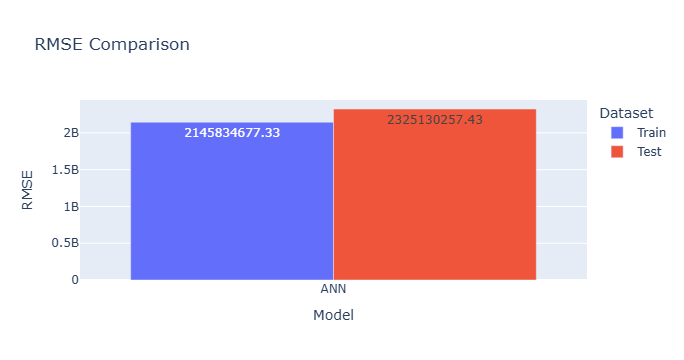

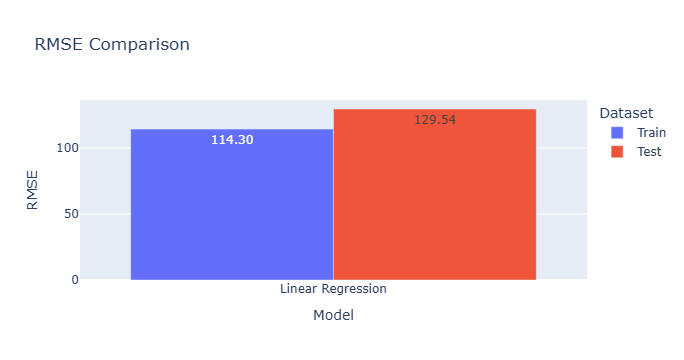

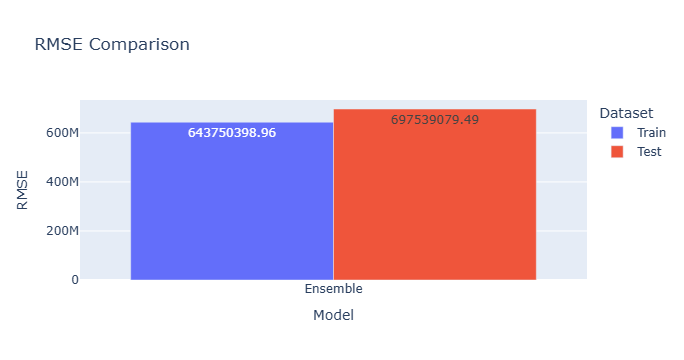

In [10]:
rmse_plot(results_ann)
rmse_plot(results_linearReg)
rmse_plot(results_ensemble)

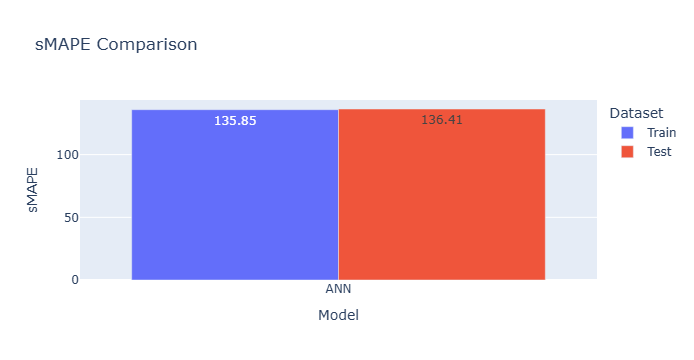

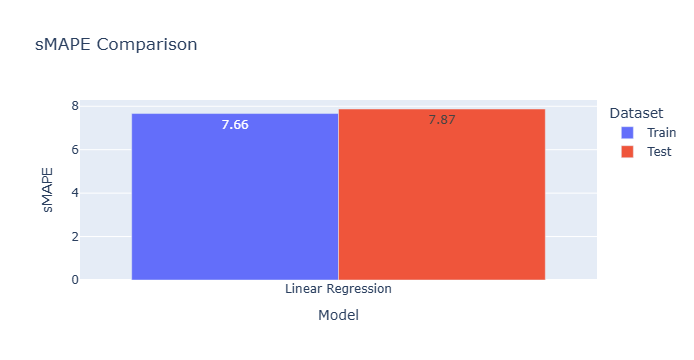

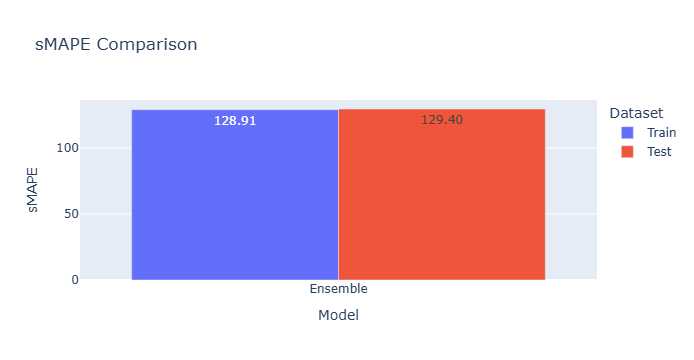

In [11]:
smape_plot(results_ann)
smape_plot(results_linearReg)
smape_plot(results_ensemble)